Dataset Shape: (8469, 17)

Accuracy Score:
19.83 %

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.12      0.14       357
Cancellation request       0.19      0.22      0.20       327
     Product inquiry       0.22      0.22      0.22       316
      Refund request       0.19      0.22      0.20       345
     Technical issue       0.21      0.22      0.22       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



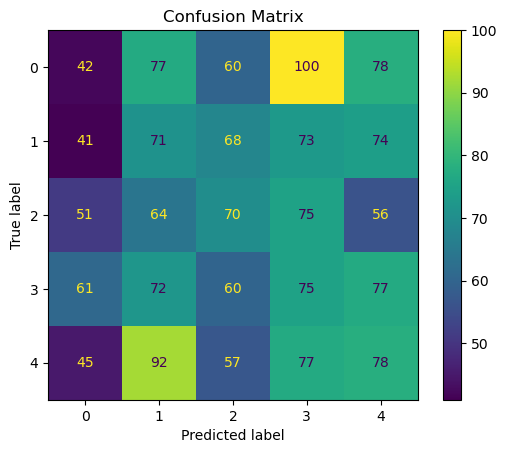

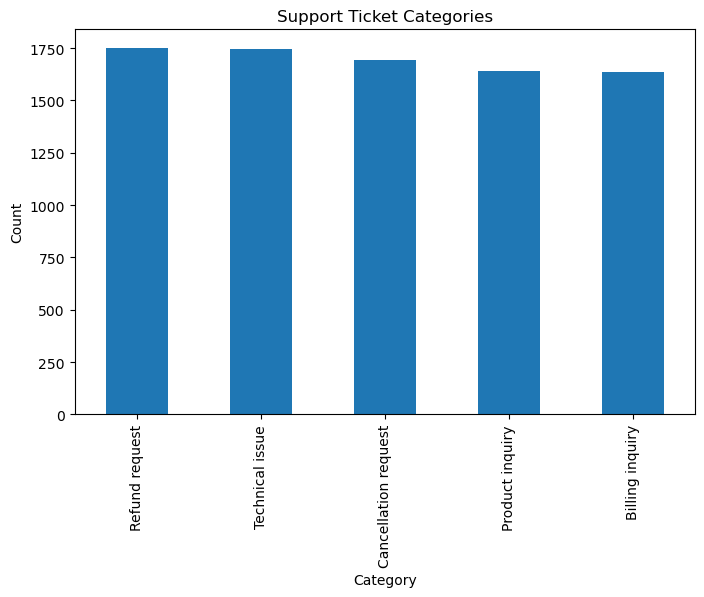

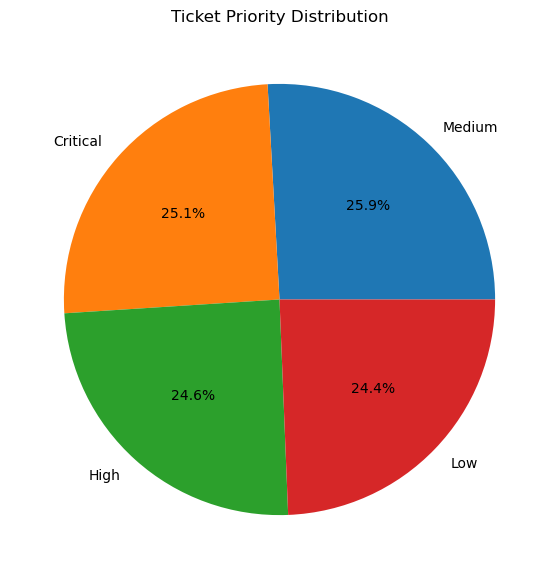


Predicted Category:
Product inquiry
Priority: Medium


In [4]:
import zipfile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

with zipfile.ZipFile("customer_support_tickets.csv.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

df = pd.read_csv("dataset/customer_support_tickets.csv")

print("Dataset Shape:", df.shape)


df = df[
    [
        "Ticket Description",
        "Ticket Type",
        "Ticket Priority"
    ]
]

df.dropna(inplace=True)

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

df["clean_text"] = df["Ticket Description"].apply(clean_text)


X = df["clean_text"]

y = df["Ticket Type"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nAccuracy Score:")
print(round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

plt.figure(figsize=(8,5))

df["Ticket Type"].value_counts().plot(
    kind="bar"
)

plt.title("Support Ticket Categories")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

plt.figure(figsize=(7,7))

df["Ticket Priority"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Ticket Priority Distribution")

plt.show()

new_ticket = [
    "My payment failed and money was deducted twice"
]

new_ticket_vector = vectorizer.transform(
    new_ticket
)

predicted_category = model.predict(
    new_ticket_vector
)

print("\nPredicted Category:")
print(predicted_category[0])


high_priority = [
    "Billing inquiry",
    "Technical issue"
]

medium_priority = [
    "Product inquiry"
]

if predicted_category[0] in high_priority:

    print("Priority: High")

elif predicted_category[0] in medium_priority:

    print("Priority: Medium")

else:

    print("Priority: Low")